# Неделя 4. Вторник
## Обучение без учителя
### Кластеризация текстов

✏️  Сегодняшним вашим заданием будет кластеразиция текстов. 

* У нас имеется выборка из 5000 сообщений из новостных телеграм каналов на разные тематики
* Необходимо предобработать данные, выделить кластеры
* Собирать будем такой папйлайн `предварительный препроцессинг` __->__ `удаление стоп-слов` __->__ `лемматизация` __->__ `векторизация текста` __->__ `понижение размерности` __->__ `кластеризация`

__1.__ Подгрузите датасет `aux/tg_channels.csv`

In [1]:
import numpy as np
import pandas as pd
import re
import regex
import string
from collections import defaultdict
from sklearn import metrics
from time import time
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.manifold import trustworthiness
import pymorphy3
import sklearn
from umap import UMAP

sklearn.set_config(transform_output="pandas")

/home/dmitry/elbrus/Phase1/ds-phase1-git/week3/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/tg_channels.csv")

In [3]:
df.head()

,content,label
0,Мужчину в метро оскорбила сумка с репродукцией...,искусство
1,В одном из кинотеатров Нидерландов перед просм...,маркетинг
2,🖼️ «Христос в Галилейском море» — Эжен Делакру...,искусство
3,"24 года Яндекс работает, чтобы делать жизнь уд...",технологии
4,Телеком 2022 - 2 прибыльных #MVNO и остальные🔥...,технологии


In [4]:
df.shape

(2000, 2)

In [5]:
df.iloc[562]

content    И опять к депутатамТам начали разгонять тему, ...
label                                              маркетинг
Name: 562, dtype: object

In [6]:
texts = df["content"].copy()
labels = df["label"].copy()

__2.__ Сделай необходимую предобработку текста `aux/tg_channels.csv`. Всю ее оберните в функцию `clean`

   * Немножко полистайте свои тексты, посмотрите проблемы, которые есть в них
   * Удалите ненужные сущности, например ссылки, смайлы, и т.д. Все, что считаете мусором и не нужным для кластеризации и только будет создавать лишние токены
  
💡 __совет__:
* Не пытайтесь сделать сразу идеальную отчистку, в разных текстах, разные проблемы, лучше сделать baseline-проходку, а дальше вернуться, уже видя проблемы и чдочищать их
* Можно сразу результат прикреплять в `DataFrame`, например создать колонку `cleaned_text`

In [7]:
# функция вставляет пробел, если внутри слова есть большая буква, например:
# И опять к депутатамТам начали -> И опять к депутатам Там начали
def insert_space(text: str):
    text_list = text.split()
    for j in range(len(text_list)):
        for i in range(1, len(text_list[j])):
            if (
                text_list[j][i].isupper()
                and text_list[j][i - 1].islower()
                and re.fullmatch(r"[а-яёА-ЯЁ]+", text_list[j])
            ):
                text_list[j] = text_list[j][:i] + " " + text_list[j][i:]
                break
    return " ".join(text_list)


# Функция, превращающая мультипробелы в 1
def squeeze_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def replace_punctuation_with_space(text: str) -> str:
    # создаём таблицу замен: каждый знак пунктуации → пробел
    # for_delete = string.punctuation[:string.punctuation.find('-')] + string.punctuation[string.punctuation.find('-') + 1:] + "«»—"
    table = str.maketrans({ch: " " for ch in string.punctuation + "«»—"})
    return text.translate(table)

In [8]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [9]:
ind = 56

In [10]:
text_sample = texts[ind]
text_sample

'Вчера впервые оказался в Гатчине, на фестивале «Ночь света». 20 инсталляций разбросанных по темному  Гатчинскому  парку. Лазеры, проекции, экраны, зеркала. Где-то таинственно, где-то жутковато, где-то очень красиво. Ночная прогулка часа на полтора, два. Что-то понравилось, что-то совсем нет, но опыт супер. Особенно, когда из темноты парка на тебя выезжает светящаяся множеством глаз колесница. Сегодня последний день. Двери, вернее, калитку, открывают в 21 00. Подробности тут. На видео — аудиовизуальная природоподобная инсталляция, Nidum от Splaces.studio'

In [11]:
text_sample = insert_space(text_sample)
text_sample = replace_punctuation_with_space(text_sample)
text_sample

'Вчера впервые оказался в Гатчине  на фестивале  Ночь света   20 инсталляций разбросанных по темному Гатчинскому парку  Лазеры  проекции  экраны  зеркала  Где то таинственно  где то жутковато  где то очень красиво  Ночная прогулка часа на полтора  два  Что то понравилось  что то совсем нет  но опыт супер  Особенно  когда из темноты парка на тебя выезжает светящаяся множеством глаз колесница  Сегодня последний день  Двери  вернее  калитку  открывают в 21 00  Подробности тут  На видео   аудиовизуальная природоподобная инсталляция  Nidum от Splaces studio'

In [12]:
text_sample = squeeze_spaces(text_sample)
text_sample

'Вчера впервые оказался в Гатчине на фестивале Ночь света 20 инсталляций разбросанных по темному Гатчинскому парку Лазеры проекции экраны зеркала Где то таинственно где то жутковато где то очень красиво Ночная прогулка часа на полтора два Что то понравилось что то совсем нет но опыт супер Особенно когда из темноты парка на тебя выезжает светящаяся множеством глаз колесница Сегодня последний день Двери вернее калитку открывают в 21 00 Подробности тут На видео аудиовизуальная природоподобная инсталляция Nidum от Splaces studio'

In [13]:
emoji_pattern = re.compile(
    "["
    "\U0001f600-\U0001f64f"  # смайлики (😀😁😂😃 ...)
    "\U0001f300-\U0001f5ff"  # символы и пиктограммы (🌍🌈🔥💡📱)
    "\U0001f680-\U0001f6ff"  # транспорт и карты (🚀🚗✈️🚦)
    "\U0001f1e0-\U0001f1ff"  # флаги (🇷🇺🇺🇸🇨🇳)
    "\U00002700-\U000027bf"  # символы типа стрелок, ✂️✈️✔
    "\U0001f900-\U0001f9ff"  # расширенные смайлы (🤟🤯🦄🥑)
    "\U00002600-\U000026ff"  # солнце, звёзды, знаки зодиака ☀️⭐♑
    "\U00002b00-\U00002bff"  # стрелки и геометрические символы ⬆️⬇️⏩
    "]+",
    flags=re.UNICODE,
)
text_sample = insert_space(text_sample)
text_sample = text_sample.lower()
text_sample = re.sub(r"\d+", "", text_sample)
text_sample = re.sub(r"@\w+", "", text_sample)
text_sample = re.sub(r"http\S+", "", text_sample)  # удаляем ссылки
text_sample = regex.sub(r"[\p{Cc}\p{Cf}]", "", text_sample)
text_sample = emoji_pattern.sub(r"", text_sample)
text_sample = replace_punctuation_with_space(text_sample)
text_sample = squeeze_spaces(text_sample)
# text_sample = re.sub(r"https\S+", " ", text_sample)  # удаляем ссылки

text_sample

'вчера впервые оказался в гатчине на фестивале ночь света инсталляций разбросанных по темному гатчинскому парку лазеры проекции экраны зеркала где то таинственно где то жутковато где то очень красиво ночная прогулка часа на полтора два что то понравилось что то совсем нет но опыт супер особенно когда из темноты парка на тебя выезжает светящаяся множеством глаз колесница сегодня последний день двери вернее калитку открывают в подробности тут на видео аудиовизуальная природоподобная инсталляция nidum от splaces studio'

In [14]:
def clean(text_sample):
    emoji_pattern = re.compile(
        "["
        "\U0001f600-\U0001f64f"  # смайлики (😀😁😂😃 ...)
        "\U0001f300-\U0001f5ff"  # символы и пиктограммы (🌍🌈🔥💡📱)
        "\U0001f680-\U0001f6ff"  # транспорт и карты (🚀🚗✈️🚦)
        "\U0001f1e0-\U0001f1ff"  # флаги (🇷🇺🇺🇸🇨🇳)
        "\U00002700-\U000027bf"  # символы типа стрелок, ✂️✈️✔
        "\U0001f900-\U0001f9ff"  # расширенные смайлы (🤟🤯🦄🥑)
        "\U00002600-\U000026ff"  # солнце, звёзды, знаки зодиака ☀️⭐♑
        "\U00002b00-\U00002bff"  # стрелки и геометрические символы ⬆️⬇️⏩
        "]+",
        flags=re.UNICODE,
    )

    text_sample = re.sub(r"\d+", " ", text_sample)  # удаляем числа
    text_sample = re.sub(r"@\w+", " ", text_sample)  # удаляем теги @username
    text_sample = re.sub(r"#\w+", " ", text_sample)  # удаляем хэштеги
    text_sample = re.sub(r"http\S+", " ", text_sample)  # удаляем ссылки
    text_sample = regex.sub(
        r"[\p{Cc}\p{Cf}]", "", text_sample
    )  # удаляем символы разметки
    text_sample = emoji_pattern.sub(r" ", text_sample)  # удаляем смайлики
    text_sample = insert_space(text_sample)
    text_sample = text_sample.lower()
    text_sample = replace_punctuation_with_space(text_sample)
    text_sample = squeeze_spaces(text_sample)  # нижний регистр
    return text_sample

In [15]:
rand_ind = np.random.randint(2000)
text_sample2 = texts[rand_ind]
print(rand_ind)
text_sample2

127


'Не можем вспомнить такое лето, как сейчас. В плане залпа выставочных блокбастеров. Обычно лето - сезон «мертвый», но живем в особенные времена. Вот, например, в Русском музее масштабно дают Врубеля, к 165-летию художника недавно закончилась выставка и в московской Третьяковке. И тем, кто был на первой, и тем, кто собирается увидеть в Петербурге, советуем потратить время на совместный проект музея и «ВКонтакте». В небольших видеороликах экскурсовод Серафима Коломейцева рассказывает и про демонов, и про пернатых царевен, про эмоциональные маятники художника и то, к чему это чуть не привело. «Михаил Врубель. К 165-летию со дня рождения» открыта до 2 августа: 220 работ из Русского музея, Третьяковки и частных коллекций.'

In [16]:
text_sample2 = clean(text_sample2)
text_sample2

'не можем вспомнить такое лето как сейчас в плане залпа выставочных блокбастеров обычно лето сезон мертвый но живем в особенные времена вот например в русском музее масштабно дают врубеля к летию художника недавно закончилась выставка и в московской третьяковке и тем кто был на первой и тем кто собирается увидеть в петербурге советуем потратить время на совместный проект музея и вконтакте в небольших видеороликах экскурсовод серафима коломейцева рассказывает и про демонов и про пернатых царевен про эмоциональные маятники художника и то к чему это чуть не привело михаил врубель к летию со дня рождения открыта до августа работ из русского музея третьяковки и частных коллекций'

In [17]:
text_sample3 = texts[rand_ind]
text_sample3 = clean(text_sample3)
text_sample3

'не можем вспомнить такое лето как сейчас в плане залпа выставочных блокбастеров обычно лето сезон мертвый но живем в особенные времена вот например в русском музее масштабно дают врубеля к летию художника недавно закончилась выставка и в московской третьяковке и тем кто был на первой и тем кто собирается увидеть в петербурге советуем потратить время на совместный проект музея и вконтакте в небольших видеороликах экскурсовод серафима коломейцева рассказывает и про демонов и про пернатых царевен про эмоциональные маятники художника и то к чему это чуть не привело михаил врубель к летию со дня рождения открыта до августа работ из русского музея третьяковки и частных коллекций'

__3.__ Удалите __стоп-слова__. Оберните в функцию `clean`

💡 __Небольшая подсказка__:
* В демо-файле с лекции мы подгружали список английских стоп-слов `stopwords.words('english')`, там есть и русский `stopwords.words('russian')`. Можете попробовать взять его, однако он содержит в себе не так много стоп-слов нашего языка
* [Здесь](https://github.com/stopwords-iso/stopwords-ru/blob/master/stopwords-ru.txt) добрые люди сделали более расширенный список стоп-слов, есть идея его подгрузить, дабы работало лучше

In [18]:
stopwords_df = pd.read_csv("data/stopwords-ru.txt", header=None)
stopwords_ru = stopwords_df.iloc[:, 0].to_list()
# + [
#     "канал",
#     "яндекс",
#     "реклама",
#     "компания",
# ]

In [19]:
def remove_stopwords(text):
    result = []
    text_list = text.split()
    for c in text_list:
        if c not in stopwords_ru:
            result.append(c)
    return " ".join(result)

__4.__ Проведите __лемматизацию__ или __стемминг__, что считаете нужным. Оберните в функцию `lemmitize`.

❗В демо-файле была работа над англоязычными текстами. Здесь текст русский, лемматизации в `nltk` для него нет.  
* Нам поможет [pymorphy3](https://pypi.org/project/pymorphy3/), работающий с русскими текстами.
      
* Ниже представлен небольшой пример. Можете попробовать попреобразовать разные слова и посмотреть результат, далее примените к своим текстам

In [20]:
# #pip install pymorphy3

morph = pymorphy3.MorphAnalyzer()
morph.parse("делают")[0].normal_form

'делать'

In [21]:
def lemmitize(text: str):
    lemm_text_list = []
    text_list = text.split()
    for c in text_list:
        lemm_text_list.append(morph.parse(c)[0].normal_form)
    return " ".join(lemm_text_list)

In [22]:
lemmitize(text_sample3)

'не мочь вспомнить такой лето как сейчас в план залп выставочный блокбастер обычно лето сезон мёртвый но жить в особенный время вот например в русский музей масштабно давать врубель к летие художник недавно закончиться выставка и в московский третьяковка и тем кто быть на первый и тем кто собираться увидеть в петербург советовать потратить время на совместный проект музей и вконтакте в небольшой видеоролик экскурсовод серафим коломейцев рассказывать и про демон и про пернатый царевна про эмоциональный маятник художник и то к что это чуть не привести михаил врубель к летие с день рождение открыть до август работа из русский музей третьяковка и частный коллекция'

#### Собираем функцию полной подготовки текста

In [23]:
def preprocessing(text):
    text = clean(text)
    text = lemmitize(text)
    text = remove_stopwords(text)
    reg_tokenizer = RegexpTokenizer("\w+")
    return " ".join(reg_tokenizer.tokenize(text))

In [24]:
texts[1999]

'Выбираете ординатуру?\xa0Подсказываем: в Госпитале им. Н. Н. Бурденко открыт прием на 11 направлений!Ординатура в Госпитале Бурденко —\xa0 это:\xa0практика на новейшем оборудовании;преподаватели — практикующие специалисты с многолетним опытом лечения пациентов;уникальные клинические случаи.Стоимость обучения: от 200 000 в год.Старт приема документов — 3 июля!\xa0Ознакомиться с направлениями ординатуры и перечнем документов можно на сайте: https://gvkg.ru/education/postupayushchim-v-ordinaturu/Заполните форму, и с вами свяжутся представители приемной комиссии, чтобы ответить на все вопросы:\xa0Форма для заявки'

In [25]:
preprocessing(texts[4])

'телек прибыльный остальной сегодня фнс опубликовать bo nalog ru результат подводить итог телеком публиковать результат тинькофф право mvno оператор сбер мотив показать рост yoy таттелек заметка условие ттк живой ржд ттк связь mvno положить акадо упасть прибыль молчать эра телек показать разумеется годный excel ссылка приложение забывать продолжение'

In [26]:
texts_preproc = texts.map(preprocessing)
texts_preproc.iloc[-1]

KeyboardInterrupt: 

In [ ]:
# text_ready = []
# for c in texts_preproc.values:
#     text_ready += c

# len(text_ready)

In [ ]:
texts_preproc.head()

0    мужчина метро оскорбить сумка репродукция карт...
1    кинотеатр нидерланды просмотр ужастик крик гро...
2    христос галилейский море эжен делакруа картина...
3                             яндекс удобный поддержка
4    телек прибыльный остальной сегодня фнс опублик...
Name: content, dtype: object

__5.__ Векторизуйте тексты, любым способом `Tf-Idf`, `CountVetorizer`, [`HashingVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html). Отвекторизованный текст сохраните в `matrix_of_texts`

📑 Про более подробную работу `HashingVetorizer` можно почитать [тут](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html)

💡 __совет__:
* Создайте как датафрейм, матрицу(пример в демо), можно понять будет сколько токенов образовалось и каких

In [ ]:
vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=10,
    stop_words="english",
)
X_tfidf = vectorizer.fit_transform(texts_preproc)
print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

n_samples: 2000, n_features: 1493


In [ ]:
X_tfidf = pd.DataFrame(
    data=X_tfidf.toarray(), columns=vectorizer.get_feature_names_out()
)
X_tfidf

,ai,android,api,apple,breaking,chatgpt,code,digital,facebook,google,...,эффективно,эффективность,эффективный,ютуба,являться,явно,язык,январь,яндекс,яркий
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.473934,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,0.0,0.183017,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1996,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.200683,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1997,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1998,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.433261,0.000000,0.0


__6.__ Понизьте размерность любым способом `TruncatedSVD`/`umap`. Сохраните результат в `reduced_matrix_of_texts`

In [ ]:
tsvd = make_pipeline(TruncatedSVD(n_components=5), Normalizer(copy=False))

In [ ]:
X_tfidf_tsvd = tsvd.fit_transform(X_tfidf)

__7.__ Проведи кластеризацию c помощью `K-means`, количество кластеров попробуйте сделать 5

In [ ]:
evaluations = []
evaluations_std = []


### функция проверки


def fit_and_evaluate(km, X, name=None, n_runs=5):
    name = km.__class__.__name__ if name is None else name

    train_times = []
    scores = defaultdict(list)
    for seed in range(n_runs):
        km.set_params(random_state=seed)
        t0 = time()
        km.fit(X)
        train_times.append(time() - t0)
        scores["Homogeneity"].append(metrics.homogeneity_score(labels, km.labels_))
        scores["Completeness"].append(metrics.completeness_score(labels, km.labels_))
        scores["V-measure"].append(metrics.v_measure_score(labels, km.labels_))
        scores["Adjusted Rand-Index"].append(
            metrics.adjusted_rand_score(labels, km.labels_)
        )
        scores["Silhouette Coefficient"].append(metrics.silhouette_score(X, km.labels_))
    train_times = np.asarray(train_times)

    print(f"clustering done in {train_times.mean():.2f} ± {train_times.std():.2f} s ")
    evaluation = {
        "estimator": name,
        "train_time": train_times.mean(),
    }
    evaluation_std = {
        "estimator": name,
        "train_time": train_times.std(),
    }
    for score_name, score_values in scores.items():
        mean_score, std_score = np.mean(score_values), np.std(score_values)
        print(f"{score_name}: {mean_score:.3f} ± {std_score:.3f}")
        evaluation[score_name] = mean_score
        evaluation_std[score_name] = std_score
    evaluations.append(evaluation)
    evaluations_std.append(evaluation_std)

In [ ]:
km = KMeans(n_clusters=5, n_init=50, random_state=42, max_iter=500)

In [ ]:
fit_and_evaluate(km, X_tfidf_tsvd, name="KMeans\nwith LSA on tf-idf vectors")

clustering done in 0.14 ± 0.02 s 
Homogeneity: 0.295 ± 0.002
Completeness: 0.307 ± 0.002
V-measure: 0.301 ± 0.002
Adjusted Rand-Index: 0.275 ± 0.005
Silhouette Coefficient: 0.320 ± 0.002


__8.__ Выведи топ15 слов для каждого кластера

In [ ]:
new_labels = km.labels_
X_clustered = X_tfidf.copy()
X_clustered["Cluster"] = new_labels
X_clustered.head()

,ai,android,api,apple,breaking,chatgpt,code,digital,facebook,google,...,эффективность,эффективный,ютуба,являться,явно,язык,январь,яндекс,яркий,Cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.473934,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,4


In [ ]:
grouped_by_cluster = X_clustered.groupby("Cluster").mean()
grouped_by_cluster

,ai,android,api,apple,breaking,chatgpt,code,digital,facebook,google,...,эффективно,эффективность,эффективный,ютуба,являться,явно,язык,январь,яндекс,яркий
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.005853,0.005559,0.005826,0.011536,0.010114,0.009521,0.001072,0.002535,0.006128,0.009454,...,0.001456,0.001410,0.001953,0.003700,0.002842,0.001067,0.007489,0.001212,0.027432,0.001042
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000778,0.000000,0.000000,0.000000,...,0.002571,0.003984,0.006288,0.000000,0.006523,0.002068,0.000969,0.002349,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000754,0.000000,0.000000,0.002047,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.009148,0.001296,0.002883,0.005786,0.000364,0.009345
3,0.000000,0.000000,0.000000,0.002680,0.001823,0.001456,0.000000,0.005093,0.000000,0.001367,...,0.000882,0.004691,0.000850,0.000000,0.001959,0.003586,0.003384,0.001741,0.000463,0.003022
4,0.001878,0.000000,0.000284,0.004169,0.001832,0.001896,0.003847,0.001811,0.000292,0.001307,...,0.000000,0.001239,0.001496,0.001642,0.005203,0.002658,0.006031,0.003224,0.005409,0.001632


In [ ]:
grouped_by_cluster.loc[0, :].T.sort_values(ascending=False)[:15]

канал           0.033732
яндекс          0.027432
приложение      0.019588
пользователь    0.019303
компания        0.018682
сервис          0.016904
видео           0.015690
пост            0.015404
ссылка          0.015277
сайт            0.014787
telegram        0.014485
интересный      0.013228
фильм           0.013226
рекламный       0.013077
появиться       0.013000
Name: 0, dtype: float64

In [ ]:
top_15 = {}

for c in grouped_by_cluster.index:
    top_15[f"Cluster {c}"] = (
        grouped_by_cluster.loc[c, :].T.sort_values(ascending=False).index[:15]
    )

In [ ]:
for c in top_15.keys():
    print(f"Cluster {c}:", *top_15[c])

Cluster Cluster 0: канал яндекс приложение пользователь компания сервис видео пост ссылка сайт telegram интересный фильм рекламный появиться
Cluster Cluster 1: врач ребёнок организм университет пациент препарат совершенный мужчина педиатрический медицинский лечение боль заболевание здоровье больница
Cluster Cluster 2: картина художник музей искусство выставка портрет цвет любовь произведение век сюжет девушка автор написать коллекция
Cluster Cluster 3: реклама роскомсвобода агент иностранный бренд рекламный настоящий рынок либо информация деятельность касаться канал произвести интернет
Cluster Cluster 4: рассказать урок узнать пройти система статья проект результат компания команда помощь курс университет решение рубль


In [ ]:
original_space_centroids = tsvd[0].inverse_transform(km.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(5):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :15]:
        print(f"{terms[ind]} ", end="")
    print()

Cluster 0: канал яндекс компания приложение пользователь проект ссылка сайт сервис интересный рекламный видео пост telegram курс 
Cluster 1: врач университет ребёнок педиатрический пациент медицинский мужчина организм лечение помощь препарат больница заболевание подробный здоровье 
Cluster 2: картина художник музей выставка искусство портрет любовь девушка произведение написать создать автор история цвет сюжет 
Cluster 3: реклама канал роскомсвобода бренд рекламный компания агент иностранный рынок социальный ролик информация интернет настоящий telegram 
Cluster 4: яндекс университет канал врач проект компания помощь рассказать ребёнок пройти сайт приложение система подробный команда 


__9.__ Посчитай внутренние(`silhouette_score`) и внешние метрики(`rand_score`). Для внешник метрик у вас есть разметка в исходных данных в столбце `label`

In [ ]:
sil_score = metrics.silhouette_score(X_tfidf, km.labels_, sample_size=2000)
rand_score = metrics.rand_score(km.labels_, labels)
homo = metrics.homogeneity_score(labels, km.labels_)
compl = metrics.completeness_score(labels, km.labels_)
scores = pd.DataFrame(
    data={
        "silhouette_score": sil_score,
        "rand_score": rand_score,
        "Homogeneity": homo,
        "Completeness": compl,
    },
    index=["KMeans (n=5)"],
)
scores

,silhouette_score,rand_score,Homogeneity,Completeness
KMeans (n=5),-0.065217,0.746214,0.292866,0.305906


__10.__ Попробуйте построить `wordcloud` - ссылка на [туториал](https://www.datacamp.com/tutorial/wordcloud-python)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

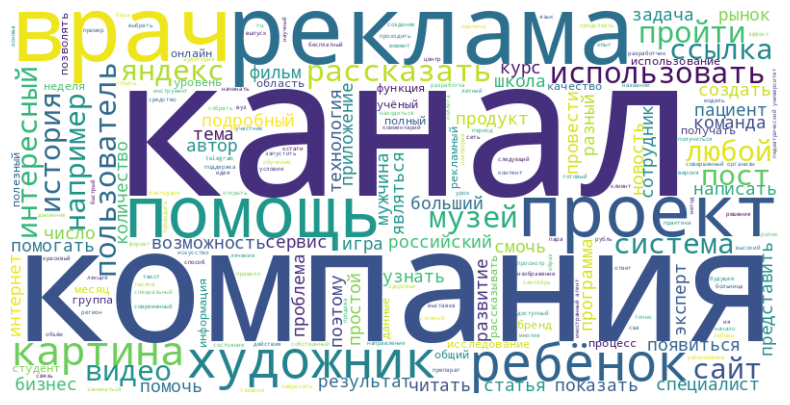

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
    " ".join(texts_preproc.to_list())
)

# Отображение
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Убираем оси
plt.show()

__11.__ Задание со звездочкой. Оберни всю работу выше в итоговый пайплайн следующего вида:  
   * `MyCustomPreprocessorText` __->__ `CountVectorizer` __->__ `TruncatedSVD` __->__ `Kmeans`
   * `MyCustomPreprocessorText` внутри себя будет содержать все этапы предобработки и очистки текста:
        - `clean` __->__ `remove_stopwords` __->__ `lemmitize`
   * Обучи и подай на вход текст "Этот текст о рекламе, о маркетинге и его пользе для любого продукта для людей" и проверь, к какому кластеру отнесется данный объект

__Некоторый шаблон в помощи сборки своего препроцессора указан ниже__

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pymorphy3


class MyCustomTextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stop_words = self.get_stopwords_list()
        self.morph = pymorphy3.MorphAnalyzer()

    def fit(
        self, X, y=None
    ):  # Препроцессору обучаться не нужно, его нужно только преобразовывать, поэтому тут пусто
        return self

    def transform(self, texts, y=None):  # Будет преобразоваывать
        return [self.preprocess(text) for text in texts]

    # Здесь можно прописать код получения словаря со стоп-словами
    def get_stopwords_list(self):
        stopwords_df = pd.read_csv(
            "data/stopwords-ru.txt",
            # "https://github.com/stopwords-iso/stopwords-ru/blob/master/stopwords-ru.txt",
            header=None,
        )
        stopwords_ru = stopwords_df.iloc[:, 0].to_list()
        return stopwords_ru

    def insert_space(self, text: str):
        text_list = text.split()
        for j in range(len(text_list)):
            for i in range(1, len(text_list[j])):
                if (
                    text_list[j][i].isupper()
                    and text_list[j][i - 1].islower()
                    and re.fullmatch(r"[а-яёА-ЯЁ]+", text_list[j])
                ):
                    text_list[j] = text_list[j][:i] + " " + text_list[j][i:]
                    break
        return " ".join(text_list)

    # Функция, превращающая мультипробелы в 1
    def squeeze_spaces(self, text: str) -> str:
        return re.sub(r"\s+", " ", text).strip()

    # Функция замены знаков пунктуации
    def replace_punctuation_with_space(self, text: str) -> str:
        table = str.maketrans({ch: " " for ch in string.punctuation + "«»—"})
        return text.translate(table)

    # Функция по очистке текста
    def clean(self, text_sample):
        emoji_pattern = re.compile(
            "["
            "\U0001f600-\U0001f64f"  # смайлики (😀😁😂😃 ...)
            "\U0001f300-\U0001f5ff"  # символы и пиктограммы (🌍🌈🔥💡📱)
            "\U0001f680-\U0001f6ff"  # транспорт и карты (🚀🚗✈️🚦)
            "\U0001f1e0-\U0001f1ff"  # флаги (🇷🇺🇺🇸🇨🇳)
            "\U00002700-\U000027bf"  # символы типа стрелок, ✂️✈️✔
            "\U0001f900-\U0001f9ff"  # расширенные смайлы (🤟🤯🦄🥑)
            "\U00002600-\U000026ff"  # солнце, звёзды, знаки зодиака ☀️⭐♑
            "\U00002b00-\U00002bff"  # стрелки и геометрические символы ⬆️⬇️⏩
            "]+",
            flags=re.UNICODE,
        )
        text_sample = re.sub(r"\d+", " ", text_sample)  # удаляем числа
        text_sample = re.sub(r"@\w+", " ", text_sample)  # удаляем теги @username
        text_sample = re.sub(r"#\w+", " ", text_sample)  # удаляем хэштеги
        text_sample = re.sub(r"http\S+", " ", text_sample)  # удаляем ссылки
        text_sample = regex.sub(
            r"[\p{Cc}\p{Cf}]", "", text_sample
        )  # удаляем символы разметки
        text_sample = emoji_pattern.sub(r" ", text_sample)  # удаляем смайлики
        text_sample = self.insert_space(text_sample)  # вставляем пробелы
        text_sample = text_sample.lower()  # нижний регистр
        text_sample = self.replace_punctuation_with_space(
            text_sample
        )  # убираем пунктуацию
        text_sample = self.squeeze_spaces(text_sample)  # удаляем мультипробелы
        return text_sample

    def remove_stopwords(self, text):
        result = []
        text_list = text.split()
        for c in text_list:
            if c not in self.get_stopwords_list():
                result.append(c)
        return " ".join(result)

    def lemmatize(self, text):
        lemm_text_list = []
        text_list = text.split()
        for c in text_list:
            lemm_text_list.append(self.morph.parse(c)[0].normal_form)
        return " ".join(lemm_text_list)

    # Функция, которая запустит последовательный запуск всех этапов выше
    def preprocess(self, text):
        text = self.clean(text)
        text = self.lemmatize(text)
        text = self.remove_stopwords(text)
        reg_tokenizer = RegexpTokenizer("\w+")
        return " ".join(reg_tokenizer.tokenize(text))

    # def preprocess(self, text):
    #     return text.map(self.preprocess_str)

* Проверьте его, работает ли правильно transform у этого класса, если все ок 

In [ ]:
pipeline = Pipeline(
    [
        ("preprocessor", MyCustomTextPreprocessor()),
    ]
)

pipeline.fit_transform(texts)

['мужчина метро оскорбить сумка репродукция картина вчера сентябрь православный веровать скорбно праздновать усекновение глава пророк предтеча креститель господний иоанн девушка ехать метро сумка шоперо изобразить картина андреа соларио саломея иоанн креститель надпись мем забыть православный пассажир расшатать чувство веровать обратиться полиция девушка выход вагон полиция мужчина требовать посадить пассажирка случиться нервный срыв судить новость полицейский фрустрированный ситуация мужчина заявление написать требовать наказать богохульница',
 'кинотеатр нидерланды просмотр ужастик крик громко покричать экран вывести шкала оценить уровень громкость крик отрепетировать фильм',
 'христос галилейский море эжен делакруа картина посвятить сюжет описать евангелие завет плыть море иисус ученик демонстрировать христианский вера вызвать буря шквальный ветер живописец настолько захватить тема создать вариант данный тема период воссоздавать лодка парус парус представить картина нравиться автор 

In [ ]:
text_clustering_pipeline = Pipeline(
    [
        ("preprocessor", MyCustomTextPreprocessor()),
        (
            "vectorizer",
            TfidfVectorizer(
                max_df=0.5,
                min_df=30,
                stop_words="english",
            ),
        ),
        (
            "reducer",
            make_pipeline(TruncatedSVD(n_components=5), Normalizer(copy=False)),
        ),
        ("clusterizer", KMeans(n_clusters=5, n_init=50, random_state=42, max_iter=500)),
    ]
)

In [ ]:
text_clustering_pipeline.fit(texts)

,steps,"[('preprocessor', ...), ('vectorizer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


* А теперь соберите полный пайплайн и посчитайте кластер данного текста

In [ ]:
predict = text_clustering_pipeline.predict(
    ["Этот текст о рекламе, о маркетинге и его пользе для любого продукта для людей"]
)
predict

array([0], dtype=int32)

In [ ]:
len(predict)

1